In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import glob
import cv2
import csv
import os
import deep_watershed_transform_network as dwt_network
import direction_network_model as dn_model
import deep_watershed_dataset_MSE as wtn_dataset

# --- 1. Device Setup ---
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Success: Using Apple Metal (MPS) acceleration.")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA (NVIDIA).")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU (Warning: This will be slower).")

# --- 2. Setup Data ---
# --- CONFIGURATION ---
IMAGE_PATH = sorted(glob.glob("./images/**/*.png", recursive=True))
MASK_PATH = sorted(glob.glob("./masks/**/*.png", recursive=True))
VAL_IMAGE_PATH = sorted(glob.glob("./val_images/**/*.png", recursive=True))
VAL_MASK_PATH = sorted(glob.glob("./val_masks/**/*.png", recursive=True))

# STORED HEAT/DIRECTION MAPS
NPZ_TRAINING_PATH = "./training_data_MSE_npz"
NPZ_VALIDATION_PATH = "./validation_data_MSE_npz"

# --- MODEL SAvE PATHS
DN_MODEL_SAVE_PATH = "dn_model.pth"
WTN_MODEL_SAVE_PATH = "wtn_model.pth"

# DN SAVE PLOTS
train_dn_acc_history = []
val_acc_dn_history = []
loss_avg_dn_history = []
val_loss_avg_dn_history = []

# WTN SAVE PLOTS
train_wtn_mae_history = []
val_mae_wtn_history = []
loss_avg_wtn_history = []
val_loss_avg_wtn_history = []

def train(epochs, batch_size, dn_lr, wtn_lr):
    dn_best_val_loss = float("inf")
    wtn_best_val_loss = float("inf")

    train_dataset = wtn_dataset.DeepWatershedDataset(IMAGE_PATH, MASK_PATH, NPZ_TRAINING_PATH, val=False)
    val_dataset = wtn_dataset.DeepWatershedDataset(VAL_IMAGE_PATH, VAL_MASK_PATH, NPZ_VALIDATION_PATH, val=True)

    dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True, # Randomizes image order
        num_workers=4, # Uses 4 CPU cores to "pre-fetch" images so the GPU never waits
        pin_memory=True, # Locks data into a "fast-lane" in RAM for quicker GPU transfer
        persistent_workers=True # Workers stay
    )

    val_dataloader = DataLoader(
        val_dataset,
        batch_size=batch_size, # Keeps memory usage consistent with training
        shuffle=False, # No need to shuffle
        num_workers=4, # Speeds up the validation check so training resumes faster
        persistent_workers=True # Workers stay
    )

    # --- DN SETUP ---
    model_dn = dn_model.DirectionNetwork().to(DEVICE)
    # Load DN existing weights
    if os.path.isfile(DN_MODEL_SAVE_PATH):
        print(f"Loading DN model from {DN_MODEL_SAVE_PATH}")
        model_dn.load_state_dict(torch.load(DN_MODEL_SAVE_PATH, map_location=DEVICE))
    else:
        print(f"Creating DN model from scratch")

    optimizer_dn = optim.Adam(model_dn.parameters(), lr=dn_lr)
    criterion_dn = nn.MSELoss()
    # DN Scheduler
    dn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_dn,
        mode='min', # Loss will go 'min' (down)
        factor=0.5, # Cut LR in half when stuck
        patience=4, # Wait 4 epoch of no improvement before cutting
    )


    # --- WTN SETUP ---
    model_wtn = dwt_network.WatershedTransformNetwork(out_classes=1).to(DEVICE)
    # Load WTN existing weights
    if os.path.isfile(WTN_MODEL_SAVE_PATH):
        print(f"Loading WTN model from {WTN_MODEL_SAVE_PATH}")
        model_wtn.load_state_dict(torch.load(WTN_MODEL_SAVE_PATH, map_location=DEVICE))
    else:
        print(f"Creating WTN model from scratch")

    optimizer_wtn = optim.Adam(model_wtn.parameters(), lr=wtn_lr)
    criterion_wtn = nn.MSELoss() # Regression for Energy Map
    # WTN Scheduler
    wtn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_wtn,
        mode='min', # Loss will go 'min' (down)
        factor=0.5, # Cut LR in half when stuck
        patience=4 # Wait 4 epoch of no improvement before cutting
    )

    # --- Training Loop ---
    print("\nStarting Training...")
    csv_filename = 'dn_training_log.csv'
    writer_header = not os.path.exists(csv_filename)
    with open(csv_filename, 'a', newline='') as f:
        writer = csv.writer(f)
        if writer_header:
            writer.writerow(['Epoch', 'DN LR', 'DN Training Avg Loss', 'DN Training Accuracy', 'DN Validation Avg Loss', 'DN Validation Accuracy'])

    csv_filename = 'wtn_training_log.csv'
    writer_header = not os.path.exists(csv_filename)
    with open(csv_filename, 'a', newline='') as f:
        writer = csv.writer(f)
        if writer_header:
            writer.writerow(['Epoch', 'WTN LR', 'WTN Training Avg Loss', 'WTN Training MAE', 'WTN Validation Avg Loss', 'WTN Validation MAE'])


    for epoch in range(epochs):

        # --- TRAIN ---
        model_dn.train()
        model_wtn.train()
        total_dn_loss, total_wtn_loss = 0, 0
        correct_dn_train, total_dn_locations_train = 0, 0
        total_wtn_mae_train, total_wtn_pixels_train = 0, 0

        accumulation_steps = 4
        optimizer_dn.zero_grad()
        optimizer_wtn.zero_grad()

        for i, (inputs, target_dir, target_energy) in enumerate(dataloader):
            inputs, target_dir, target_energy = inputs.to(DEVICE), target_dir.to(DEVICE), target_energy.to(DEVICE)

            # Network 1 (Compass)
            pred_dir = model_dn(inputs)
            loss_dn = criterion_dn(pred_dir, target_dir)
            loss_dn = loss_dn / accumulation_steps
            loss_dn.backward()

            # Network 2 (Mountain/Island)
            inputs_wtn = pred_dir.detach()
            wtn_output = model_wtn(inputs_wtn)

            # Normalize target to match model output range (0-1) for MSE loss calculation
            target_normalised = target_energy.unsqueeze(1).float() / 15.0

            loss_wtn = criterion_wtn(wtn_output, target_normalised)
            loss_wtn = loss_wtn / accumulation_steps
            loss_wtn.backward()

            # Backward pass (accumulate the gradients)
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(dataloader):
                optimizer_dn.step()
                optimizer_wtn.step()
                optimizer_dn.zero_grad()
                optimizer_wtn.zero_grad()

            # Accumulate loss for the epoch average
            total_dn_loss += loss_dn.item() * accumulation_steps
            total_wtn_loss += loss_wtn.item() * accumulation_steps

            # Metric 1: Cosine Similarity > 0.94
            train_cos_sim = torch.nn.functional.cosine_similarity(pred_dir, target_dir, dim=1)
            foreground_mask = (target_energy > 0)
            if foreground_mask.sum() > 0:
                valid_sims = train_cos_sim[foreground_mask]
                correct_dn_train += (valid_sims >= 0.94).sum().item()
                total_dn_locations_train += foreground_mask.sum().item()

            # Metric 2: Foreground MAE (Regression Version)
            wtn_foreground_mask = (target_energy > 0)
            if wtn_foreground_mask.sum() > 0:
                # Scale prediction back up to Real Pixels (0-15) and squeeze channel dim
                pred_in_pixels = wtn_output.squeeze(1) * 15.0

                # Calculate the absolute difference strictly inside foreground instances
                abs_diff_train = torch.abs(pred_in_pixels[wtn_foreground_mask] - target_energy[wtn_foreground_mask].float())
                total_wtn_mae_train += abs_diff_train.sum().item()
                total_wtn_pixels_train += wtn_foreground_mask.sum().item()

        # Calculate Averages
        avg_dn_loss = total_dn_loss / len(dataloader)
        avg_wtn_loss = total_wtn_loss / len(dataloader)

        # DN Accuracy (Percentage)
        train_dn_acc = (correct_dn_train / total_dn_locations_train) * 100 if total_dn_locations_train > 0 else 0

        # WTN MAE (Average Error per pixel)
        train_wtn_mae = total_wtn_mae_train / total_wtn_pixels_train if total_wtn_pixels_train > 0 else 0

        # Record Average Loss (Outside batch loop, inside epoch loop)
        loss_avg_dn_history.append(avg_dn_loss)
        train_dn_acc_history.append(train_dn_acc)
        loss_avg_wtn_history.append(avg_wtn_loss)
        train_wtn_mae_history.append(train_wtn_mae)

        # --- VALIDATE ---
        model_dn.eval()
        model_wtn.eval()

        correct_dn_val, total_dn_locations_val = 0, 0
        total_wtn_mae_val, total_wtn_pixels_val = 0, 0
        v_total_dn_loss, v_total_wtn_loss = 0, 0

        with torch.no_grad():
            for v_inputs, v_target_dir, v_target_energy in val_dataloader:
                v_inputs, v_target_dir, v_target_energy = v_inputs.to(DEVICE), v_target_dir.to(DEVICE), v_target_energy.to(DEVICE)

                # Forward 1
                v_dn_outputs = model_dn(v_inputs)
                v_dn_loss = criterion_dn(v_dn_outputs, v_target_dir)
                v_total_dn_loss += v_dn_loss.item()

                # Metric 1: Cosine Similarity > 0.94
                val_cos_sim = torch.nn.functional.cosine_similarity(v_dn_outputs, v_target_dir, dim=1)
                v_foreground_mask = (v_target_energy > 0)
                if v_foreground_mask.sum() > 0:
                    val_valid_sims = val_cos_sim[v_foreground_mask]
                    correct_dn_val += (val_valid_sims >= 0.94).sum().item()
                    total_dn_locations_val += v_foreground_mask.sum().item()

                # Forward 2 (Chained)
                v_wtn_output = model_wtn(v_dn_outputs)

                # Normalize target to match model output range (0-1)
                v_target_normalised = v_target_energy.unsqueeze(1).float() / 15.0

                v_wtn_loss = criterion_wtn(v_wtn_output, v_target_normalised)
                v_total_wtn_loss += v_wtn_loss.item()

                # Metric 2: Foreground MAE (Regression Version)
                v_wtn_foreground_mask = (v_target_energy > 0)
                if v_wtn_foreground_mask.sum() > 0:
                    # Scale prediction back up to Real Pixels (0-15) and squeeze channel dim
                    v_pred_in_pixels = v_wtn_output.squeeze(1) * 15.0

                    # Calculate the absolute difference strictly inside foreground instances
                    v_abs_diff_val = torch.abs(v_pred_in_pixels[v_wtn_foreground_mask] - v_target_energy[v_wtn_foreground_mask].float())
                    total_wtn_mae_val += v_abs_diff_val.sum().item()
                    total_wtn_pixels_val += v_wtn_foreground_mask.sum().item()

        # Calculate Averages
        avg_dn_val_loss = v_total_dn_loss / len(val_dataloader)
        avg_wtn_val_loss = v_total_wtn_loss / len(val_dataloader)

        val_dn_acc = (correct_dn_val / total_dn_locations_val) * 100 if total_dn_locations_val > 0 else 0
        val_wtn_mae = total_wtn_mae_val / total_wtn_pixels_val if total_wtn_pixels_val > 0 else 0

        #Step scheduler based on VALIDATION loss
        dn_scheduler.step(avg_dn_val_loss)
        wtn_scheduler.step(avg_wtn_val_loss)

        # Store for plotting later
        val_loss_avg_dn_history.append(avg_dn_val_loss)
        val_acc_dn_history.append(val_dn_acc)
        val_loss_avg_wtn_history.append(avg_wtn_val_loss)
        val_mae_wtn_history.append(val_wtn_mae)

        current_dn_lr = optimizer_dn.param_groups[0]['lr']
        current_wtn_lr = optimizer_wtn.param_groups[0]['lr']

        # Save Best
        if avg_dn_val_loss < dn_best_val_loss:
            dn_best_val_loss = avg_dn_val_loss
            torch.save(model_dn.state_dict(), 'best_dn_model.pth')
        if avg_wtn_val_loss < wtn_best_val_loss:
            wtn_best_val_loss = avg_wtn_val_loss
            torch.save(model_wtn.state_dict(), 'best_wtn_model.pth')
            predict_full_size_image(model_dn=model_dn, model_wtn=model_wtn, dir_name="best_predicted_results")

        # -- DN SAVE LOG--
        dn_log_data = [epoch + 1, current_dn_lr, avg_dn_loss, train_dn_acc, avg_dn_val_loss, val_dn_acc]
        with open('dn_training_log.csv', 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(dn_log_data)

        # -- WTN SAVE LOG--
        wtn_log_data = [epoch + 1, current_wtn_lr, avg_wtn_loss, train_wtn_mae, avg_wtn_val_loss, val_wtn_mae]
        with open('wtn_training_log.csv', 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(wtn_log_data)

        # -- PRINT OUTPUT DATA --
        print(f"Epoch {epoch + 1}/{epochs}| LR: DN={current_dn_lr}, WTN={current_wtn_lr} | Training Loss: DN={avg_dn_loss:.4f}, WTN={avg_wtn_loss:.4f} | Val Metrics: DN Acc={val_dn_acc:.1f}%, WTN Error={val_wtn_mae:.1f}")

    # Save in general
    torch.save(model_dn.state_dict(), DN_MODEL_SAVE_PATH)
    torch.save(model_wtn.state_dict(), WTN_MODEL_SAVE_PATH)
    print(f"Training Finished: DN Model saved to {DN_MODEL_SAVE_PATH}, WTN model saved to {WTN_MODEL_SAVE_PATH}")

    predict_full_size_image(model_dn=model_dn, model_wtn=model_wtn, dir_name="predicted_results")
    return train_dn_acc_history, val_acc_dn_history, loss_avg_dn_history, val_loss_avg_dn_history, loss_avg_wtn_history, val_loss_avg_wtn_history, train_wtn_mae_history, val_mae_wtn_history


def predict_full_size_image(model_dn, model_wtn, dir_name):
    print(f"\nRunning Inference on 5 FULL SIZE image...")
    model_dn.eval()
    model_wtn.eval()
    os.makedirs(dir_name, exist_ok=True)

    # Loop through first 5 images
    for i, (img_path, mask_path) in enumerate(zip(IMAGE_PATH[:5], MASK_PATH[:5])):
        # 1. Load image and Mask
        img_bgr = cv2.imread(img_path)
        mask_gray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if img_bgr is None or mask_gray is None: continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # 2. Preprocess Mask (Create Binary 0 or 1)
        h, w = img_rgb.shape[:2]
        if mask_gray.shape != (h, w):
            mask_gray = cv2.resize(mask_gray, (w, h), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_gray > 128).astype(np.uint8)
        mask_float = mask_bin.astype(np.float32)

        # 3. Normalize to match logic
        img_norm = img_rgb.astype(np.float32) / 255.0
        img_norm = (img_norm - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])

        mask_expanded = np.expand_dims(mask_float, axis=2)
        rgb_gated = img_norm * mask_expanded
        input_np = np.concatenate([rgb_gated, mask_expanded], axis=2)

        input_tensor = torch.from_numpy(input_np).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            # Inference Chain
            direction_pred = model_dn(input_tensor)
            energy_logits = model_wtn(direction_pred)
            # Handle Regression Output
            pred_map = energy_logits.squeeze().cpu().numpy()

        # Visualisation for Continuous Data
        foreground_pixels = pred_map[mask_bin > 0]

        if len(foreground_pixels) > 0:
            actual_max = foreground_pixels.max()
            scale_factor = actual_max if actual_max > 1.0 else 1.0
            vis_map = (pred_map / scale_factor) * 255
        else:
            vis_map = pred_map * 0
        vis_map = np.clip(vis_map, 0, 255).astype(np.uint8)

        # Apply Jet Colormap
        heatmap_jet = cv2.applyColorMap(vis_map, cv2.COLORMAP_JET)
        heatmap_jet[mask_bin == 0] = [0, 0, 0]

        base_name = os.path.basename(img_path)
        cv2.imwrite(f"{dir_name}/{base_name}.png", heatmap_jet)
    print(f"Success! Saved '{dir_name}' folder.")


EPOCH = 25
BATCH_SIZE = 4 # Keep (hardware limits)
DN_LR = 3e-4 # Based on LR Finder
WTN_LR = 2e-4# LR Fail. Real LR.
train_dn_acc_hist, val_acc_dn_hist, loss_avg_dn_hist, val_loss_avg_dn_hist, loss_avg_wtn_hist, val_loss_avg_wtn_hist, train_wtn_mae_hist, val_mae_wtn_hist = train(EPOCH, BATCH_SIZE, DN_LR, WTN_LR)

'''
--- Debugging ---
DN Learning Rate: 3e-4
WTN Learning Rate: 2e-4
Hardware Batch Size: 4
Accumulation Steps: 4
Epoch: 25
Resolution: 512x512

-Calculate Settings-
Overall images = 1,920
Virtual Length (return): 1,920 x 2 = 3,840
Effective batch size = 16 (4 hardware batch x 4 accumulation steps)
Golden Rule: ~6,000 total learning step for establish trendlines
Steps: 3,840 images / 16 batch size = 240 steps
Total steps needed: ~6,000
Epoch Calc: 6,000 / 240 = 25 Epochs
Scheduler Patience = 2 (drop LR after 2 bad epochs)
Estimated Time: ~2.5 hours roughly
'''

'''
--- Training ---
DN Learning Rate: 3e-4
WTN Learning Rate: 2e-4
Hardware Batch Size: 4
Accumulation Steps: 4
Epoch: 15
Resolution: 512x512

-Calculate Settings-
Overall images = 27,600
Virtual Length (return): 27,600 x 2 = 55,200
Effective batch size = 16 (4 hardware batch x 4 accumulation steps)
Golden Rule: ~50,000 total learning step for fine-tuning convergence
Steps: 55,200 images / 16 batch size = 3,450 steps
Total steps needed: ~50,000
Epoch Calc: 50,000 / 3,450 ≈ 14.5 Epochs (Round up to 15) = 15 Epochs
Scheduler Patience = 2 (drop LR after 2 bad epochs)
Estimated Time: ~15.5 hours roughly
'''



Using CUDA (NVIDIA).
Total training images found: 1920
Total training masks found: 1920

Total training heatmaps found: 1920

Total validation images found: 240
Total validation masks found: 240

Total validation heatmaps found: 240

Creating DN model from scratch
Creating WTN model from scratch

Starting Training...

Running Inference on 5 FULL SIZE image...
Success! Saved 'best_predicted_results' folder.
Epoch 1/25| LR: DN=0.0003, WTN=0.0002 | Training Loss: DN=0.0373, WTN=0.0196 | Val Metrics: DN Acc=87.0%, WTN Error=2.1

Running Inference on 5 FULL SIZE image...
Success! Saved 'best_predicted_results' folder.
Epoch 2/25| LR: DN=0.0003, WTN=0.0002 | Training Loss: DN=0.0165, WTN=0.0102 | Val Metrics: DN Acc=90.7%, WTN Error=2.0

Running Inference on 5 FULL SIZE image...
Success! Saved 'best_predicted_results' folder.
Epoch 3/25| LR: DN=0.0003, WTN=0.0002 | Training Loss: DN=0.0136, WTN=0.0096 | Val Metrics: DN Acc=92.1%, WTN Error=1.9

Running Inference on 5 FULL SIZE image...
Succe

'\n--- Training ---\nDN Learning Rate: 3e-4\nWTN Learning Rate: 2e-4\nHardware Batch Size: 4\nAccumulation Steps: 4\nEpoch: 15\nResolution: 512x512\n\n-Calculate Settings-\nOverall images = 27,600\nVirtual Length (return): 27,600 x 2 = 55,200\nEffective batch size = 16 (4 hardware batch x 4 accumulation steps)\nGolden Rule: ~50,000 total learning step for fine-tuning convergence\nSteps: 55,200 images / 16 batch size = 3,450 steps\nTotal steps needed: ~50,000\nEpoch Calc: 50,000 / 3,450 ≈ 14.5 Epochs (Round up to 15) = 15 Epochs\nScheduler Patience = 2 (drop LR after 2 bad epochs)\nEstimated Time: ~15.5 hours roughly\n'

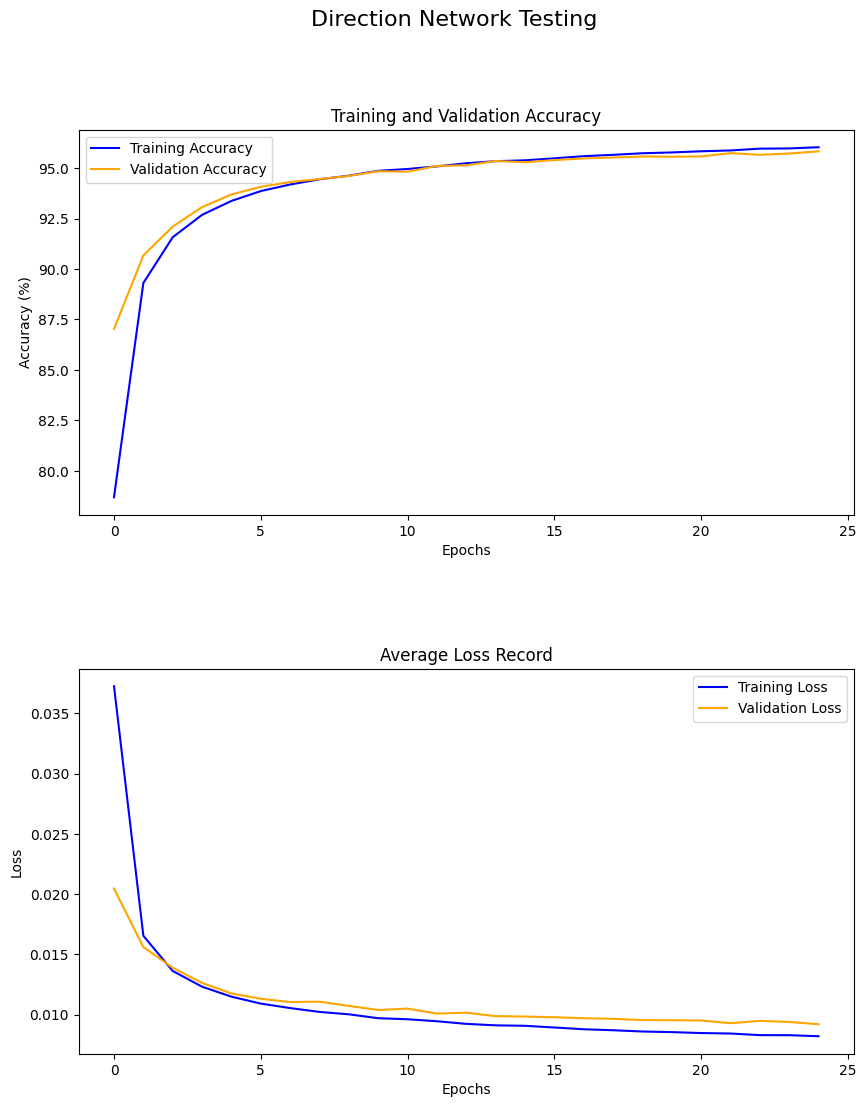

In [2]:
# --- DN VISUALIZATION ---
fig, ax = plt.subplots(2, 1, figsize=(10, 12))
ax[0].plot(train_dn_acc_hist, label='Training Accuracy', color='blue')
ax[0].plot(val_acc_dn_hist, label='Validation Accuracy', color='orange')
ax[0].set_title('Training and Validation Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy (%)')
ax[0].legend()

ax[1].plot(loss_avg_dn_hist, label='Training Loss', color='blue')
ax[1].plot(val_loss_avg_dn_hist, label='Validation Loss', color='orange')
ax[1].set_title('Average Loss Record')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.subplots_adjust(hspace=0.4)
plt.suptitle('Direction Network Testing', fontsize=16)
plt.show()

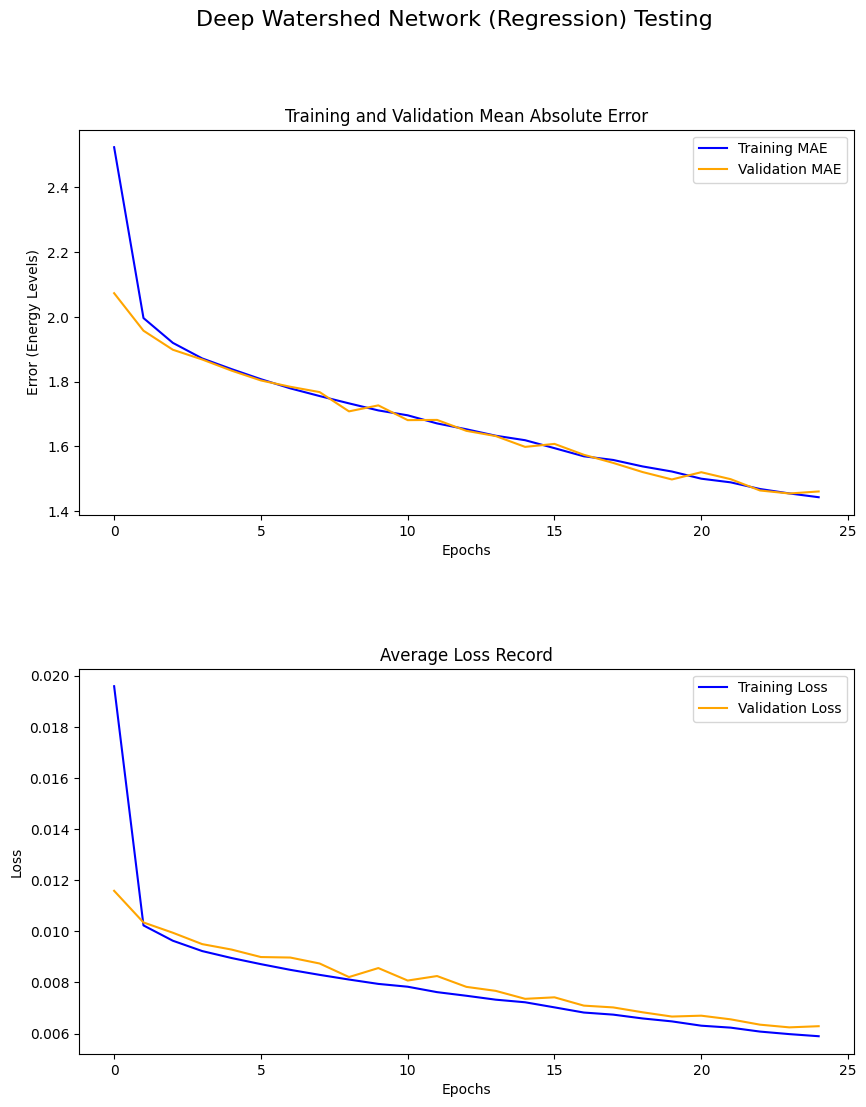

In [3]:
# --- WTN VISUALIZATION ---
fig, ax = plt.subplots(2, 1, figsize=(10, 12))
ax[0].plot(train_wtn_mae_hist, label='Training MAE', color='blue')
ax[0].plot(val_mae_wtn_hist, label='Validation MAE', color='orange')
ax[0].set_title('Training and Validation Mean Absolute Error')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Error (Energy Levels)')
ax[0].legend()

ax[1].plot(loss_avg_wtn_hist, label='Training Loss', color='blue')
ax[1].plot(val_loss_avg_wtn_hist, label='Validation Loss', color='orange')
ax[1].set_title('Average Loss Record')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.subplots_adjust(hspace=0.4)
plt.suptitle('Deep Watershed Network (Regression) Testing', fontsize=16)
plt.show()